# Import 



In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import talib
from datetime import datetime
import xgboost as xgb
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import shap
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import shap
import matplotlib.pyplot as plt
import optuna
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from optuna.samplers import TPESampler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import learning_curve
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve


# Download stock data



In [2]:

stock = 'KO'
# W projekcie zastosowano ceny skorygowane (auto_adjust=True), aby wyeliminować nieciągłości wynikające ze splitów i dywidend.
df = yf.download(stock, start='2017-01-01', end='2026-01-01', auto_adjust = True)

df.columns = df.columns.get_level_values(0)
df['Volume'] = df['Volume'].astype(float)
#Posortowanie po dacie, aby miec pewnosc ze dane sa chronologiczne
df = df.sort_index()
assert df.index.is_monotonic_increasing
# Upewnienie się, że nie mam pustych dni (np. weekend, święta)
df.isna().sum()


[*********************100%***********************]  1 of 1 completed


Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2017-01-03,31.518013,31.525555,31.125923,31.291808,14711000.0
2017-01-04,31.404909,31.646195,31.359667,31.578333,9959400.0
2017-01-05,31.480312,31.563255,31.314427,31.412450,8968300.0
2017-01-06,31.472769,31.525550,31.321964,31.442607,10246600.0
2017-01-09,31.156092,31.352138,31.073149,31.088230,14822500.0


# Wskaźniki giełdowe


# 2. Data Leakage handling
Na potrzeby pracy:
W dniu n model zna dane rynkowe z dnia n (po zamknięciu), a przewiduje ruch w przyszłości (n+1..n+h). Wszystkie cechy są konstruowane wyłącznie z danych historycznych ≤ n

## 3. Inżynieria Cech (Feature Engineering) i Etykietowanie Danych

In [4]:
# Przygotowanie danych do TA-Lib

close = df['Close'].to_numpy(dtype=float)
high  = df['High'].to_numpy(dtype=float)
low   = df['Low'].to_numpy(dtype=float)
volume = df['Volume'].to_numpy(dtype=float)


# ============================================================
# 2. FEATURE ENGINEERING (as-of t, EOD)
# ============================================================

# --- Returns (log) ---
df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
# używa Close(t) i Close(t-1) → OK w EOD

# --- Momentum / Trend ---
df['RSI'] = talib.RSI(close, timeperiod=14)
df['ADX'] = talib.ADX(high, low, close, timeperiod=14)

# MACD histogram (momentum, nie poziom)
_, _, df['MACD_hist'] = talib.MACD(
    close, fastperiod=12, slowperiod=26, signalperiod=9
)

# --- Volatility ---
df['ATR_Relative'] = talib.ATR(high, low, close, timeperiod=14) / df['Close']

# --- Distance-to-average (relative, no scale issues) ---
sma20 = talib.SMA(close, timeperiod=20)
ema50 = talib.EMA(close, timeperiod=50)

df['Dist_SMA_20'] = (df['Close'] - sma20) / sma20
df['Dist_EMA_50'] = (df['Close'] - ema50) / ema50

# --- Bollinger Bands (relative info only) ---
upper, middle, lower = talib.BBANDS(close, timeperiod=20)
df['BB_Width'] = (upper - lower) / middle
df['Percent_BB'] = (df['Close'] - lower) / (upper - lower)

# --- Volume & Flow ---
df['Relative_Volume'] = df['Volume'] / df['Volume'].rolling(window=20).mean()
# rolling mean do dnia t → OK

df['CMF'] = talib.ADOSC(
    high, low, close, volume, fastperiod=3, slowperiod=10
)

df['ROC_10'] = talib.ROC(close, timeperiod=10)

# --- Market efficiency (trend vs noise) ---
direction = (df['Close'] - df['Close'].shift(10)).abs()
volatility = (df['Close'] - df['Close'].shift(1)).abs().rolling(10).sum()
df['Efficiency_Ratio'] = direction / (volatility + 1e-10)

# --- Cycles ---
df['HT_Period'] = talib.HT_DCPERIOD(close)

# --- Calendar & gap ---
df['DayOfWeek'] = df.index.dayofweek

df['Gap'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)
# Gap(t) znany dopiero po otwarciu dnia t → OK przy EOD

# --- 3. TRIPLE BARRIER METHOD (TARGET) ---
def get_tbm_labels(price_series, returns_series, days=5, vol_mult=1.5):
    vol = returns_series.rolling(window=20).std()
    labels = []

    for i in range(len(price_series) - days):
        p_now = price_series.iloc[i]
        sigma = vol.iloc[i]

        if pd.isna(sigma):
            labels.append(0)
            continue

        b_up = p_now * (1 + sigma * vol_mult)
        b_down = p_now * (1 - sigma * vol_mult)

        future = price_series.iloc[i+1 : i+days+1]

        hit_up = future[future >= b_up].index.min()
        hit_down = future[future <= b_down].index.min()

        if pd.isna(hit_up) and pd.isna(hit_down):
            labels.append(0)
        elif pd.isna(hit_down) or (hit_up is not None and hit_up < hit_down):
            labels.append(1)
        else:
            labels.append(-1)

    labels.extend([0] * days)
    return labels

df['Target'] = get_tbm_labels(df['Close'], df['Returns'])


# 4. Usuwanie surowych cen (zostają tylko cechy)
raw_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df_final = df.drop(columns=raw_cols).copy()

# --- Usuwamy NaN po wskaźnikach ---
df_final = df_final.dropna().copy()

# sanity check
assert df_final.index.is_monotonic_increasing

print("Gotowe dane:")
print("Shape:", df_final.shape)
print("\nRozkład klas Target:")
print(df_final['Target'].value_counts(normalize=True))

df_final[['Returns', 'RSI', 'MACD_hist', 'Target']].head(10)



Gotowe dane:
Shape: (2213, 17)

Rozkład klas Target:
Target
 1    0.384998
 0    0.336195
-1    0.278807
Name: proportion, dtype: float64


Price,Returns,RSI,MACD_hist,Target
Date,,,,
2017-03-15,0.003567,62.630621,0.029590,1
2017-03-16,0.003082,64.685110,0.033921,0
2017-03-17,-0.005221,58.794367,0.022533,1
2017-03-20,0.003563,61.377061,0.019802,1
2017-03-21,0.007558,66.238161,0.030846,-1
2017-03-22,-0.002827,63.034288,0.028515,0
2017-03-23,-0.004968,57.768076,0.013490,1
2017-03-24,-0.001187,56.556349,-0.000968,1
2017-03-27,0.004737,60.155824,-0.002175,0


# 3 SPLIT danych na treningowe, do walidacji  i testowe

In [5]:
df_final = df_final.sort_index().copy()
assert df_final.index.is_monotonic_increasing

# Proporcje 
train_ratio = 0.70
val_ratio   = 0.15  # reszta = test

n = len(df_final)
train_end = int(n * train_ratio)
val_end   = int(n * (train_ratio + val_ratio))

train_df = df_final.iloc[:train_end].copy()
val_df   = df_final.iloc[train_end:val_end].copy()
test_df  = df_final.iloc[val_end:].copy()

print(" Split sizes:")
print("Train:", train_df.shape, "|", train_df.index.min().date(), "->", train_df.index.max().date())
print("Val  :", val_df.shape,   "|", val_df.index.min().date(), "->", val_df.index.max().date())
print("Test :", test_df.shape,  "|", test_df.index.min().date(), "->", test_df.index.max().date())

print("\n Target distribution (train/val/test):")
print("Train:\n", train_df['Target'].value_counts(normalize=True))
print("\nVal:\n", val_df['Target'].value_counts(normalize=True))
print("\nTest:\n", test_df['Target'].value_counts(normalize=True))

 Split sizes:
Train: (1549, 17) | 2017-03-15 -> 2023-05-09
Val  : (332, 17) | 2023-05-10 -> 2024-09-04
Test : (332, 17) | 2024-09-05 -> 2025-12-31

 Target distribution (train/val/test):
Train:
 Target
 1    0.396385
 0    0.341511
-1    0.262105
Name: proportion, dtype: float64

Val:
 Target
 1    0.394578
-1    0.307229
 0    0.298193
Name: proportion, dtype: float64

Test:
 Target
 0    0.349398
-1    0.328313
 1    0.322289
Name: proportion, dtype: float64



## 3. Inżynieria Cech i Zaawansowane EDA (Metodologia)
Przeprowadzam sekcej EDA na danych Testowych


Missing values in TRAIN (top 15):
Price
Returns             0
RSI                 0
ADX                 0
MACD_hist           0
ATR_Relative        0
Dist_SMA_20         0
Dist_EMA_50         0
BB_Width            0
Percent_BB          0
Relative_Volume     0
CMF                 0
ROC_10              0
Efficiency_Ratio    0
HT_Period           0
DayOfWeek           0
dtype: int64

 Train head preview:


Price,Returns,RSI,ADX,MACD_hist,ATR_Relative,Dist_SMA_20,Dist_EMA_50,BB_Width,Percent_BB,Relative_Volume,CMF,ROC_10,Efficiency_Ratio,HT_Period,DayOfWeek,Gap,Target
Date,,,,,,,,,,,,,,,,,
2017-03-15,0.003567,62.630621,21.047756,0.029590,0.008249,0.014337,0.021784,0.049009,0.792544,1.483693,6.878962e+06,0.786922,0.231551,23.743184,2,0.000238,1
2017-03-16,0.003082,64.685110,22.069188,0.033921,0.008464,0.014824,0.023936,0.039613,0.874229,1.080723,7.997668e+06,0.360061,0.121949,24.589612,3,-0.002136,0
2017-03-17,-0.005221,58.794367,23.017659,0.022533,0.008479,0.008098,0.017862,0.036263,0.723316,2.409503,-2.807223e+06,-0.186050,0.053914,25.185062,4,0.000710,1
2017-03-20,0.003563,61.377061,23.898383,0.019802,0.008370,0.010109,0.020634,0.032707,0.809059,0.745953,-7.648871e+06,0.882659,0.282637,25.300909,0,0.001666,1
2017-03-21,0.007558,66.238161,25.335649,0.030846,0.008470,0.016065,0.027234,0.032764,0.990331,1.115981,-6.850895e+06,2.107939,0.610397,25.049623,1,0.003082,-1


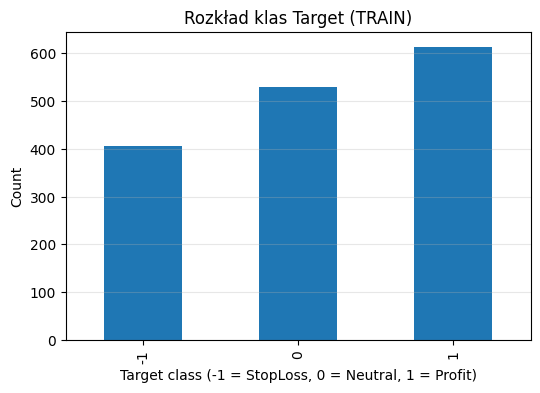

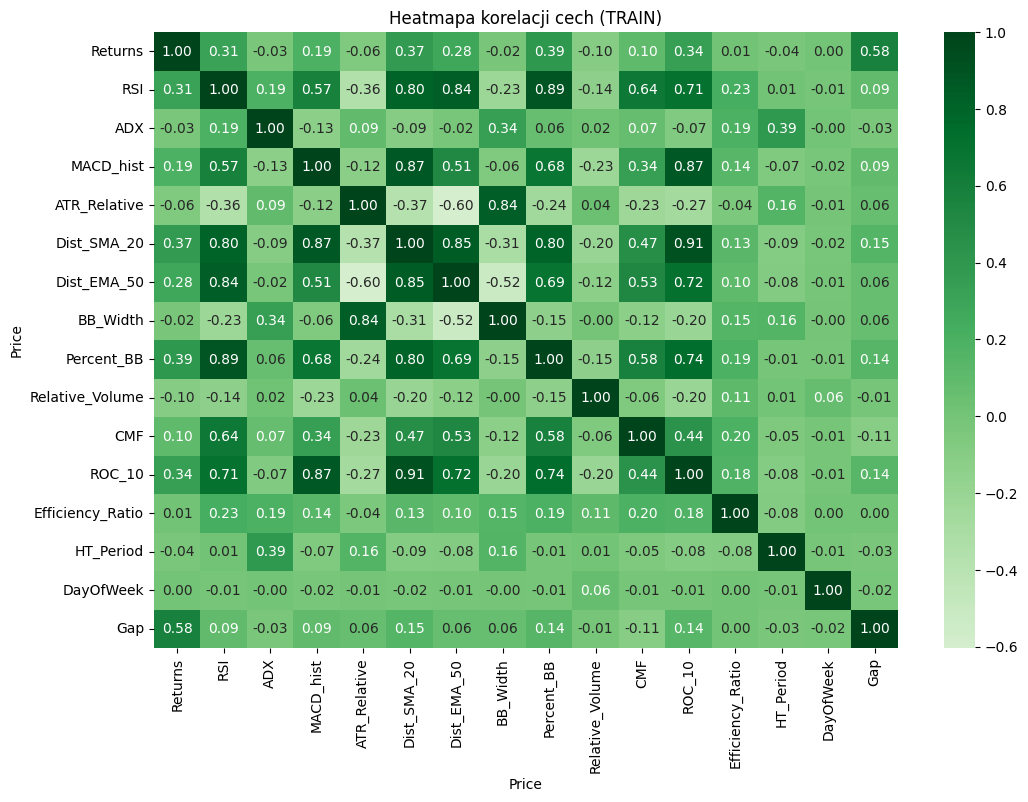


 Shapes: 
Train: (1549, 17)
Val  : (332, 17)
Test : (332, 17)


In [6]:
print("Missing values in TRAIN (top 15):")
print(train_df.isna().sum().sort_values(ascending=False).head(15))

print("\n Train head preview:")
display(train_df.head())

# Target counts
plt.figure(figsize=(6, 4))
train_df['Target'].value_counts().sort_index().plot(kind='bar')
plt.title("Rozkład klas Target (TRAIN)")
plt.xlabel("Target class (-1 = StopLoss, 0 = Neutral, 1 = Profit)")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

X_train = train_df.drop(columns=['Target']).copy()

corr = X_train.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap='Greens',      # zielona paleta
    center=0,
    annot=True,         # pokazuje liczby
    fmt=".2f"           # format liczb
)
plt.title("Heatmapa korelacji cech (TRAIN)")
plt.show()



print("\n Shapes: ")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

## Usunięcie korelacji > 80

 Features to drop due to correlation > 0.8 (based on TRAIN only):
['Dist_SMA_20', 'Dist_EMA_50', 'BB_Width', 'Percent_BB', 'ROC_10']


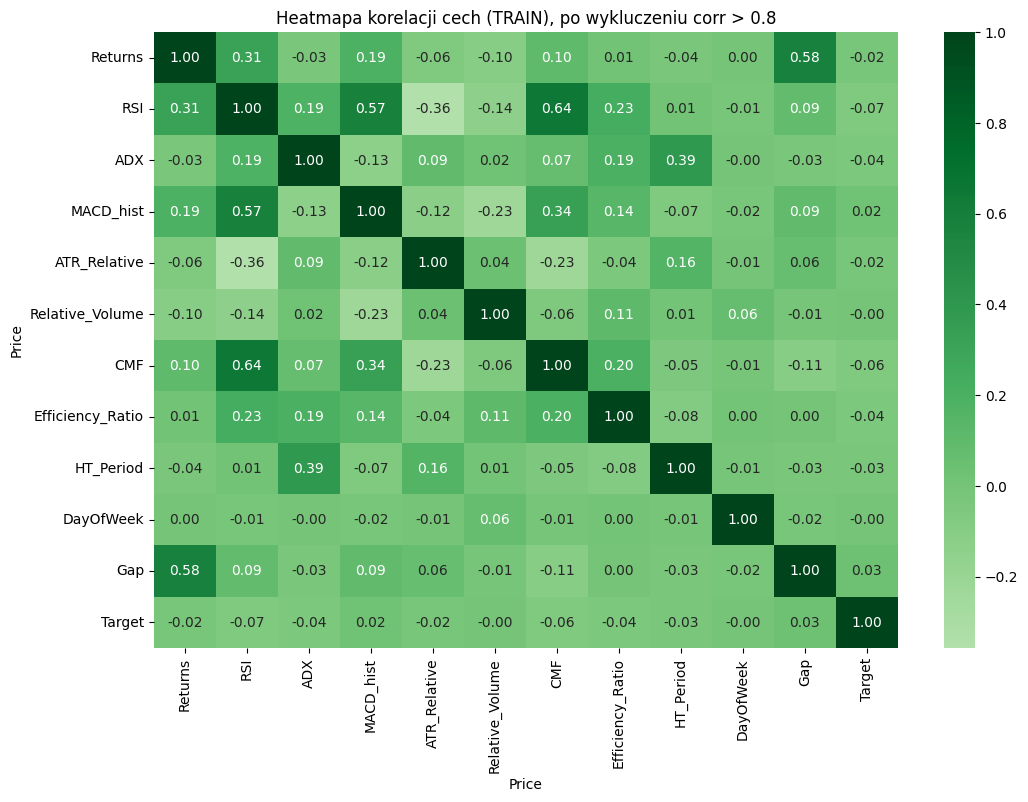

In [7]:
threshold = 0.8 # ile musi wyniesc korelacja by je wykluczyć
corr_abs = X_train.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print(f" Features to drop due to correlation > {threshold} (based on TRAIN only):")
print(to_drop)

# Apply same drops to train/val/test to avoid leakage
train_df_filtered = train_df.drop(columns=to_drop)
val_df_filtered   = val_df.drop(columns=to_drop)
test_df_filtered  = test_df.drop(columns=to_drop)




corr = train_df_filtered.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap='Greens',      # zielona paleta
    center=0,
    annot=True,         # pokazuje liczby
    fmt=".2f"           # format liczb
)
plt.title("Heatmapa korelacji cech (TRAIN), po wykluczeniu corr > 0.8")
plt.show()

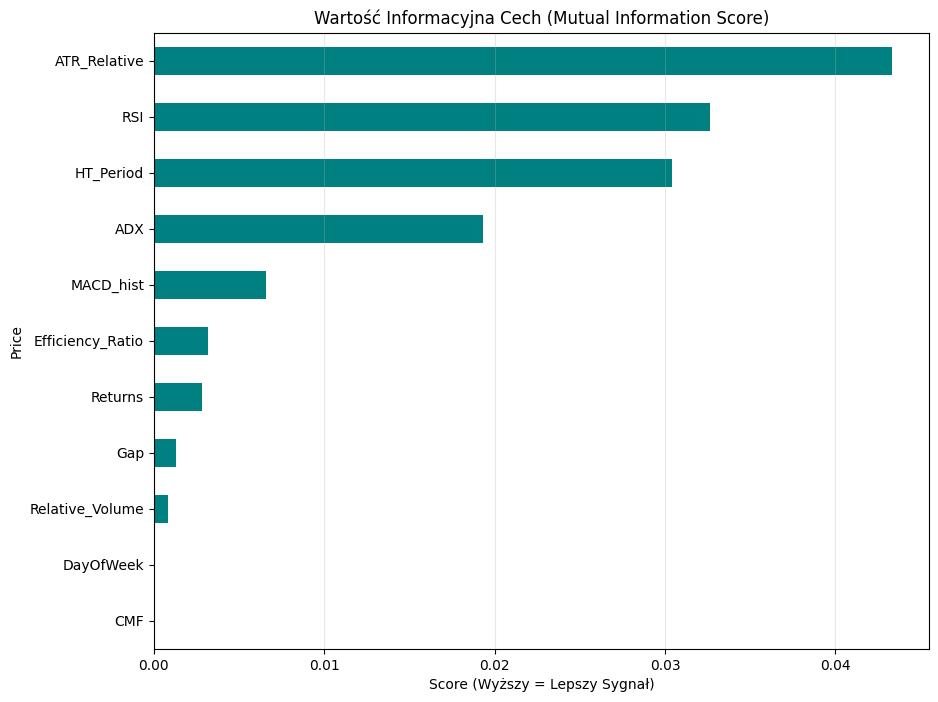

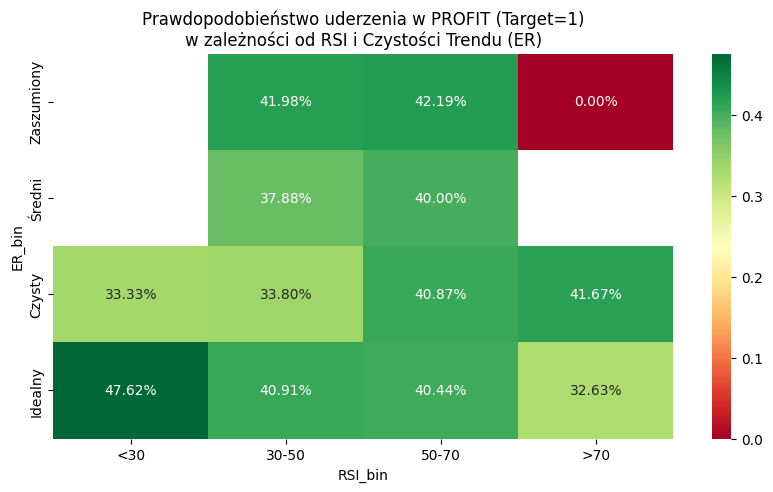

<Figure size 1000x400 with 0 Axes>

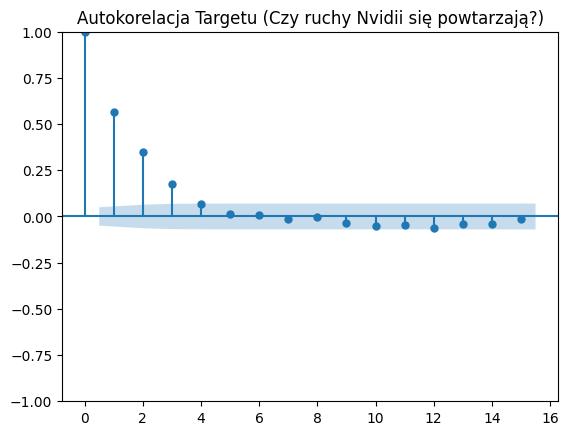

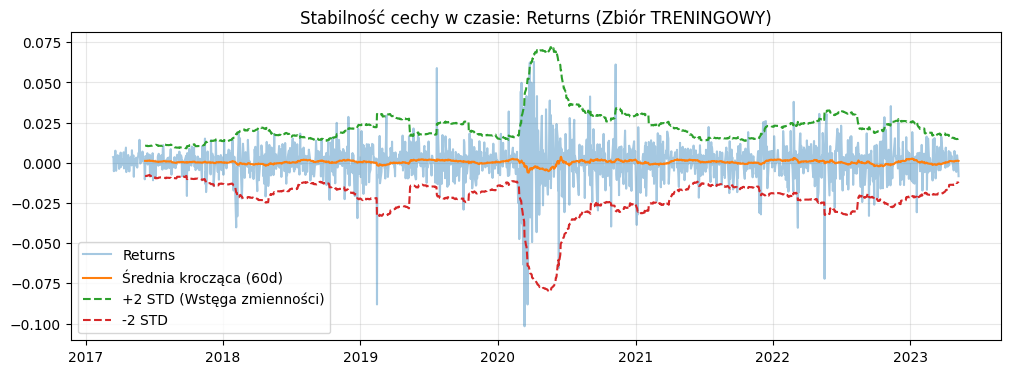

In [8]:

#   1. Mutual Information (Która cecha faktycznie wpływa na Target?) 
X_eda = train_df_filtered.drop(columns=['Target'])
y_eda = train_df_filtered['Target']
mi_scores = mutual_info_classif(X_eda, y_eda, discrete_features=False, random_state=42)

mi_series = pd.Series(mi_scores, index=X_eda.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
mi_series.plot(kind='barh', color='teal')
plt.title("Wartość Informacyjna Cech (Mutual Information Score)")
plt.xlabel("Score (Wyższy = Lepszy Sygnał)")
plt.grid(axis='x', alpha=0.3)
plt.show()

#  2. HEATMAPA PRAWDOPODOBIEŃSTWA (Strategia TBM) 
# Analizujemy, kiedy szansa na Profit (Target=1) jest największa
temp_df = train_df_filtered.copy()
temp_df['RSI_bin'] = pd.cut(temp_df['RSI'], bins=[0, 30, 50, 70, 100], labels=['<30', '30-50', '50-70', '>70'])
temp_df['ER_bin'] = pd.qcut(temp_df['Efficiency_Ratio'], q=4, labels=['Zaszumiony', 'Średni', 'Czysty', 'Idealny'])

prob_table = temp_df[temp_df['Target'] == 1].groupby(['ER_bin', 'RSI_bin'], observed=False).size() / \
             temp_df.groupby(['ER_bin', 'RSI_bin'], observed=False).size()

plt.figure(figsize=(10, 5))
sns.heatmap(prob_table.unstack(), annot=True, cmap='RdYlGn', fmt='.2%')
plt.title('Prawdopodobieństwo uderzenia w PROFIT (Target=1)\nw zależności od RSI i Czystości Trendu (ER)')
plt.show()

#  3. ANALIZA AUTOKORELACJI (ACF) 
# Sprawdzamy, czy rynek ma "pamięć" (czy wczorajszy ruch wpływa na dzisiejszy)
plt.figure(figsize=(10, 4))
plot_acf(train_df_filtered['Target'], lags=15)
plt.title("Autokorelacja Targetu (Czy ruchy Nvidii się powtarzają?)")
plt.show()

#  4. STABILNOŚĆ CECHY W CZASIE (Feature Drift) 
# Sprawdzamy, czy charakterystyka zwrotów nie zmienia się drastycznie
feature_to_plot = 'Returns'  

rolling_mean = train_df_filtered[feature_to_plot].rolling(60).mean()
rolling_std  = train_df_filtered[feature_to_plot].rolling(60).std()

plt.figure(figsize=(12, 4))
plt.plot(train_df_filtered.index, train_df_filtered[feature_to_plot], alpha=0.4, label=feature_to_plot)
plt.plot(train_df_filtered.index, rolling_mean, label="Średnia krocząca (60d)")
plt.plot(train_df_filtered.index, rolling_mean + 2*rolling_std, linestyle='--', label="+2 STD (Wstęga zmienności)")
plt.plot(train_df_filtered.index, rolling_mean - 2*rolling_std, linestyle='--', label="-2 STD")
plt.title(f"Stabilność cechy w czasie: {feature_to_plot} (Zbiór TRENINGOWY)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Przygotowanie finalnego DataSet

In [9]:
# --- 1. Przygotowanie listy cech do wyrzucenia na podstawie MI ---
# Wybieramy cechy, których MI Score jest bliski zeru 
weak_features = mi_series[mi_series < 0.005].index.tolist()
print("Cechy do usunięcia (niski MI score):", weak_features)

# --- TARGETY (Wspólne dla obu wersji) ---
y_train = train_df_filtered['Target']
y_val   = val_df_filtered['Target']
y_test  = test_df_filtered['Target']

# --- 2. DATASET V1: Tylko po korelacji (Filtered) ---
X_train_v1 = train_df_filtered.drop(columns=['Target'])
X_val_v1   = val_df_filtered.drop(columns=['Target'])
X_test_v1  = test_df_filtered.drop(columns=['Target'])

# --- 3. DATASET V2: Korelacja + MI Selection (Smart) ---
X_train_v2 = X_train_v1.drop(columns=weak_features)
X_val_v2   = X_val_v1.drop(columns=weak_features)
X_test_v2  = X_test_v1.drop(columns=weak_features)

print("\n--- FINALNE KSZTAŁTY ---")
print(f"V1 (Tylko korelacja): {X_train_v1.shape[1]} cech")
print(f"V2 (Korelacja + MI):  {X_train_v2.shape[1]} cech")
print(f"Targety: Train={len(y_train)}, Val={len(y_val)}, Test={len(y_test)}")

Cechy do usunięcia (niski MI score): ['CMF', 'DayOfWeek', 'Relative_Volume', 'Gap', 'Returns', 'Efficiency_Ratio']

--- FINALNE KSZTAŁTY ---
V1 (Tylko korelacja): 11 cech
V2 (Korelacja + MI):  5 cech
Targety: Train=1549, Val=332, Test=332


## 4. 1. Model XGBoost - dataset V1 - tylko usunięcie korelacji


[I 2026-02-01 21:20:56,479] A new study created in memory with name: no-name-1e477be7-db28-47f9-8db5-cfc5dc483da6


Nowe klasy: [0 1 2]


[I 2026-02-01 21:20:56,753] Trial 0 finished with value: 0.41566265060240964 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'min_child_weight': 40, 'gamma': 6.387926357773329, 'subsample': 0.6468055921327309, 'colsample_bytree': 0.6467983561008608}. Best is trial 0 with value: 0.41566265060240964.
[I 2026-02-01 21:20:56,893] Trial 1 finished with value: 0.4126506024096386 and parameters: {'learning_rate': 0.011430983876313222, 'max_depth': 5, 'min_child_weight': 34, 'gamma': 7.372653200164409, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 0.41566265060240964.
[I 2026-02-01 21:20:56,961] Trial 2 finished with value: 0.4397590361445783 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 2, 'min_child_weight': 17, 'gamma': 2.650640588680904, 'subsample': 0.6912726728878613, 'colsample_bytree': 0.7574269294896714}. Best is trial 2 with value: 0.4397590361445783.
[I 2026-02-01 21:20:57,054] Tria

[0]	validation_0-mlogloss:1.09819
[100]	validation_0-mlogloss:1.09493
[172]	validation_0-mlogloss:1.09376


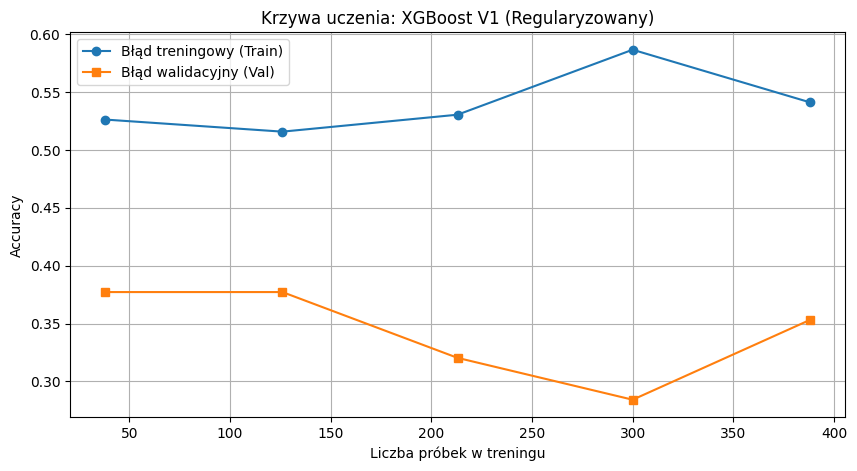


--- Raport Klasyfikacji (XGBoost V1) ---
              precision    recall  f1-score   support

          -1       0.33      0.24      0.28       109
           0       0.39      0.60      0.48       116
           1       0.43      0.31      0.36       107

    accuracy                           0.39       332
   macro avg       0.39      0.38      0.37       332
weighted avg       0.39      0.39      0.37       332



In [10]:
# Inicjalizacja LabelEncodera
le = LabelEncoder()

# Mapowanie: -1 -> 0, 0 -> 1, 1 -> 2
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

print("Nowe klasy:", np.unique(y_train_encoded)) #   [0 1 2]

# 1. Przygotowanie wag dla klas (walczymy z biasem w stronę wzrostów)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

def objective(trial):
    param = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'early_stopping_rounds': 50,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        
        # ZMNIEJSZAMY GŁĘBOKOŚĆ (tak jak w RF), aby walczyć z niskim accuracy
        'max_depth': trial.suggest_int('max_depth', 2, 5), 
        
        # DODAJEMY REGULARYZACJĘ
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 50),
        'gamma': trial.suggest_float('gamma', 1, 10), # Im wyższa, tym model bardziej konserwatywny
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        
        'n_estimators': 1000,
        'n_jobs': -1,
        'random_state': 42
    }

    model = xgb.XGBClassifier(**param)
    # Dodajemy sample_weight do fit
    model.fit(X_train_v1, y_train_encoded, 
              eval_set=[(X_val_v1, y_val_encoded)], 
              sample_weight=sample_weights,
              verbose=False)
    
    preds = model.predict(X_val_v1)
    return accuracy_score(y_val_encoded, preds)

# Optymalizacja Optuna
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=20)

# Finalny model z najlepszymi parametrami
best_params = study.best_params
best_params.update({'objective': 'multi:softprob', 'num_class': 3, 'n_estimators': 2000, 'early_stopping_rounds': 50})

final_model_xgb = xgb.XGBClassifier(**best_params)
final_model_xgb.fit(X_train_v1, y_train_encoded, 
                    eval_set=[(X_val_v1, y_val_encoded)], 
                    sample_weight=sample_weights,
                    verbose=100)

# --- 2. Wykres Krzywej Uczenia (Ten sam co w RF) ---
def plot_overfitting_analysis_xgb(model, X, y, title):
    from sklearn.model_selection import TimeSeriesSplit
    from xgboost import XGBClassifier
    
    # 1. Pobieramy wszystkie parametry z wytrenowanego modelu
    current_params = model.get_params()
    
    # 2. Usuwamy parametry, które gryzą się z learning_curve (treningowe)
    # Usuwamy early_stopping_rounds i wszelkie callbacki
    params_to_clean = ['early_stopping_rounds', 'callbacks', 'eval_metric']
    for p in params_to_clean:
        current_params.pop(p, None)
    
    # 3. Tworzymy nowy, czysty obiekt XGBClassifier z tymi samymi hiperparametrami
    # Dzięki temu learning_curve dostanie "surowy" model do nauki
    model_to_plot = XGBClassifier(**current_params)
    
    tscv = TimeSeriesSplit(n_splits=3)
    
    # n_jobs=-1 może czasem powodować błędy przy równoległym klonowaniu XGB, 
    # jeśli błąd wróci, zmień na n_jobs=1
    train_sizes, train_scores, test_scores = learning_curve(
        model_to_plot, X, y, cv=tscv, scoring='accuracy', n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5))
    
    plt.figure(figsize=(10, 5))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Błąd treningowy (Train)")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 's-', label="Błąd walidacyjny (Val)")
    plt.title(title)
    plt.xlabel("Liczba próbek w treningu")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

# Ponowne wywołanie
plot_overfitting_analysis_xgb(final_model_xgb, X_train_v1, y_train_encoded, "Krzywa uczenia: XGBoost V1 (Regularyzowany)")


# --- 3. Raport i Confusion Matrix ---
y_pred_xgb = final_model_xgb.predict(X_test_v1)
print("\n--- Raport Klasyfikacji (XGBoost V1) ---")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_.astype(str)))

## 5. 1.1 Model XGBoost - dataset V2- usunięcie korelacji, usunięcię Mutual Information <0.005



[I 2026-02-01 21:21:04,905] A new study created in memory with name: no-name-873b3b11-538f-4811-97a4-dcb6f8f04278


Nowe klasy: [0 1 2]


[I 2026-02-01 21:21:05,249] Trial 0 finished with value: 0.3855421686746988 and parameters: {'learning_rate': 0.019906996673933378, 'max_depth': 12, 'min_child_weight': 15, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 0.004207053950287938, 'reg_lambda': 0.0017073967431528124}. Best is trial 0 with value: 0.3855421686746988.
[I 2026-02-01 21:21:05,338] Trial 1 finished with value: 0.39156626506024095 and parameters: {'learning_rate': 0.12207764786954153, 'max_depth': 9, 'min_child_weight': 15, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'reg_alpha': 2.1368329072358767, 'reg_lambda': 0.0070689749506246055}. Best is trial 1 with value: 0.39156626506024095.
[I 2026-02-01 21:21:05,432] Trial 2 finished with value: 0.39457831325301207 and parameters: {'learning_rate': 0.009778325945801386, 'max_depth': 4, 'min_child_weight': 7, 'subsample': 0.762378215816119, 'colsample_bytree': 0.7159725093210578, 'reg_alpha': 0.014618962

[0]	validation_0-mlogloss:1.09468
[100]	validation_0-mlogloss:1.08885
[200]	validation_0-mlogloss:1.08831
[261]	validation_0-mlogloss:1.08997

--- Raport Klasyfikacji (V2 - Smart Selection) ---
              precision    recall  f1-score   support

          -1       0.50      0.06      0.10       109
           0       0.41      0.39      0.40       116
           1       0.33      0.65      0.44       107

    accuracy                           0.36       332
   macro avg       0.41      0.37      0.31       332
weighted avg       0.41      0.36      0.31       332



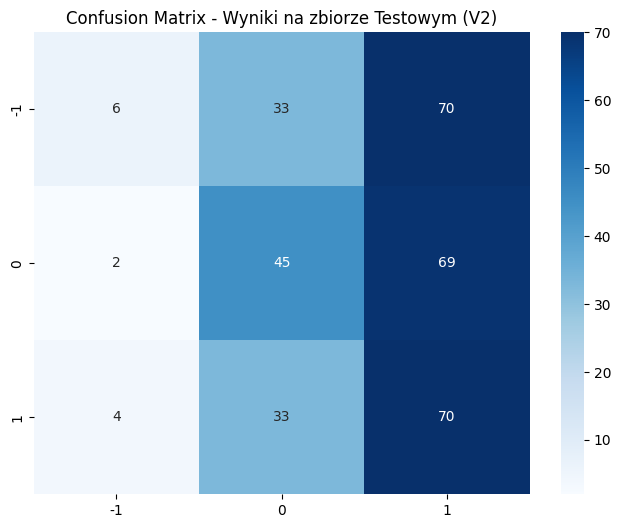

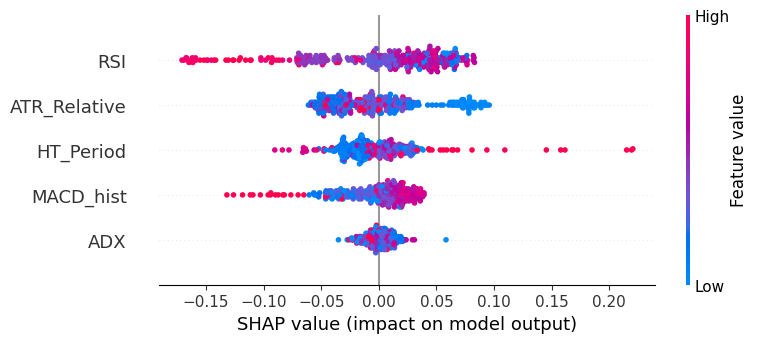

In [11]:
# Inicjalizacja LabelEncodera
le = LabelEncoder()

# Mapowanie: -1 -> 0, 0 -> 1, 1 -> 2
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

print("Nowe klasy:", np.unique(y_train_encoded)) #   [0 1 2]

def objective(trial):
    param = {
        'objective': 'multi:softprob',  
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'early_stopping_rounds': 50,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'n_estimators': 2000,
        'n_jobs': -1
    }

    model = xgb.XGBClassifier(**param)
    # PODMIANA NA V2
    model.fit(X_train_v2, y_train_encoded, eval_set=[(X_val_v2, y_val_encoded)], verbose=False)
    
    preds = model.predict(X_val_v2)
    return accuracy_score(y_val_encoded, preds)

# Optymalizacja
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=30)

# Finalny model
best_params = study.best_params
best_params.update({'objective': 'multi:softprob', 'num_class': 3, 'n_estimators': 5000, 'early_stopping_rounds': 100})

final_model = xgb.XGBClassifier(**best_params)
# PODMIANA NA V2
final_model.fit(X_train_v2, y_train_encoded, eval_set=[(X_val_v2, y_val_encoded)], verbose=100)

# Predykcja na V2
y_pred_encoded = final_model.predict(X_test_v2)
y_pred_original = le.inverse_transform(y_pred_encoded)

print("\n--- Raport Klasyfikacji (V2 - Smart Selection) ---")
print(classification_report(le.inverse_transform(y_test_encoded), y_pred_original))

# --- Confusion Matrix ---
y_test_original = le.inverse_transform(y_test_encoded)
cm = confusion_matrix(y_test_original, y_pred_original, labels=le.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Wyniki na zbiorze Testowym (V2)')
plt.show()

# --- Analiza SHAP ---
explainer = shap.Explainer(final_model, X_test_v2)
shap_values = explainer(X_test_v2)
class_idx = 2 

shap_exp_class = shap.Explanation(
    values=shap_values.values[:, :, class_idx],
    base_values=shap_values.base_values[:, class_idx],
    data=X_test_v2.values if hasattr(X_test_v2, 'values') else X_test_v2,
    feature_names=X_test_v2.columns
)
shap.plots.beeswarm(shap_exp_class, max_display=15)

## 6. 1. Model RandomForest - dane V1- usunięta korelacja


[I 2026-02-01 21:29:34,330] A new study created in memory with name: no-name-5e7c6483-1e98-4211-a677-ac7766a9f11e
[I 2026-02-01 21:29:34,772] Trial 0 finished with value: 0.4246987951807229 and parameters: {'n_estimators': 456, 'max_depth': 9, 'min_samples_leaf': 72, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.4246987951807229.
[I 2026-02-01 21:29:35,263] Trial 1 finished with value: 0.42168674698795183 and parameters: {'n_estimators': 515, 'max_depth': 4, 'min_samples_leaf': 79, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.4246987951807229.
[I 2026-02-01 21:29:35,899] Trial 2 finished with value: 0.4307228915662651 and parameters: {'n_estimators': 666, 'max_depth': 3, 'min_samples_leaf': 52, 'max_features': 'log2', 'class_weight': None}. Best is trial 2 with value: 0.4307228915662651.
[I 2026-02-01 21:29:36,343] Trial 3 finished with value: 0.4367469879518072 and parameters: {'n_estimators': 453, 'max_depth': 10, 'min_sa

Najlepsze parametry dla KO: {'n_estimators': 551, 'max_depth': 7, 'min_samples_leaf': 53, 'max_features': 'log2', 'class_weight': None}

--- Raport Klasyfikacji (Coca-Cola KO V1) ---
              precision    recall  f1-score   support

 Spadek (-1)       0.60      0.03      0.05       109
 Neutral (0)       0.36      0.37      0.36       116
  Wzrost (1)       0.34      0.66      0.45       107

    accuracy                           0.35       332
   macro avg       0.43      0.35      0.29       332
weighted avg       0.43      0.35      0.29       332



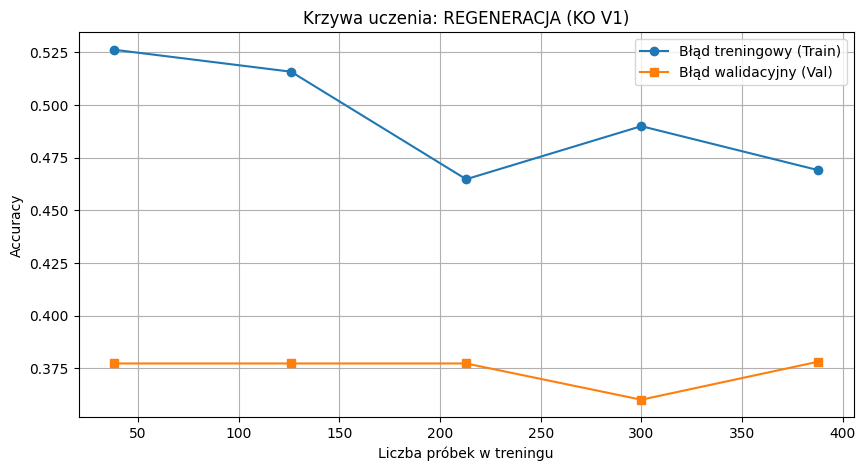

In [20]:
# 1. Definicja brakującej funkcji wykresu
def plot_overfitting_analysis(model, X, y, title):
    tscv = TimeSeriesSplit(n_splits=3)
    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=tscv, scoring='accuracy', n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5))
    
    plt.figure(figsize=(10, 5))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Błąd treningowy (Train)")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 's-', label="Błąd walidacyjny (Val)")
    plt.title(title)
    plt.xlabel("Liczba próbek w treningu")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

# 2. Twoja funkcja celu dla KO
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 700),
        'max_depth': trial.suggest_int('max_depth', 3, 10),          
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 50, 150), 
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'criterion': 'gini' 
    }
    
    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    rf.fit(X_train_v1, y_train_encoded)
    
    preds = rf.predict(X_val_v1)
    return accuracy_score(y_val_encoded, preds)

# 3. Uruchomienie tuningu
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=20)

# 4. Trenowanie Championa dla KO
best_params_rf = study_rf.best_params
print(f"Najlepsze parametry dla KO: {best_params_rf}")

rf_final_ko = RandomForestClassifier(**best_params_rf, random_state=42, n_jobs=-1)
rf_final_ko.fit(X_train_v1, y_train_encoded)

# 5. Wyniki i Wykres
y_pred_rf = rf_final_ko.predict(X_test_v1)
print("\n--- Raport Klasyfikacji (Coca-Cola KO V1) ---")
print(classification_report(y_test_encoded, y_pred_rf, 
                            target_names=['Spadek (-1)', 'Neutral (0)', 'Wzrost (1)']))

plot_overfitting_analysis(rf_final_ko, X_train_v1, y_train_encoded, "Krzywa uczenia: REGENERACJA (KO V1)")

## 6. 1.2 Model RandomForest - dane V2 - usunięta korelacja i Mutual Information


[I 2026-02-01 21:29:46,654] A new study created in memory with name: no-name-365e6d94-31b9-4b1d-976d-730400282957
[I 2026-02-01 21:29:46,902] Trial 0 finished with value: 0.39759036144578314 and parameters: {'n_estimators': 255, 'max_depth': 3, 'min_samples_leaf': 77, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.39759036144578314.
[I 2026-02-01 21:29:47,339] Trial 1 finished with value: 0.39457831325301207 and parameters: {'n_estimators': 485, 'max_depth': 3, 'min_samples_leaf': 56, 'max_features': 'log2'}. Best is trial 0 with value: 0.39759036144578314.
[I 2026-02-01 21:29:47,487] Trial 2 finished with value: 0.3644578313253012 and parameters: {'n_estimators': 131, 'max_depth': 4, 'min_samples_leaf': 58, 'max_features': 'log2'}. Best is trial 0 with value: 0.39759036144578314.
[I 2026-02-01 21:29:47,814] Trial 3 finished with value: 0.3614457831325301 and parameters: {'n_estimators': 344, 'max_depth': 5, 'min_samples_leaf': 66, 'max_features': 'log2'}. Best is trial 0 with 

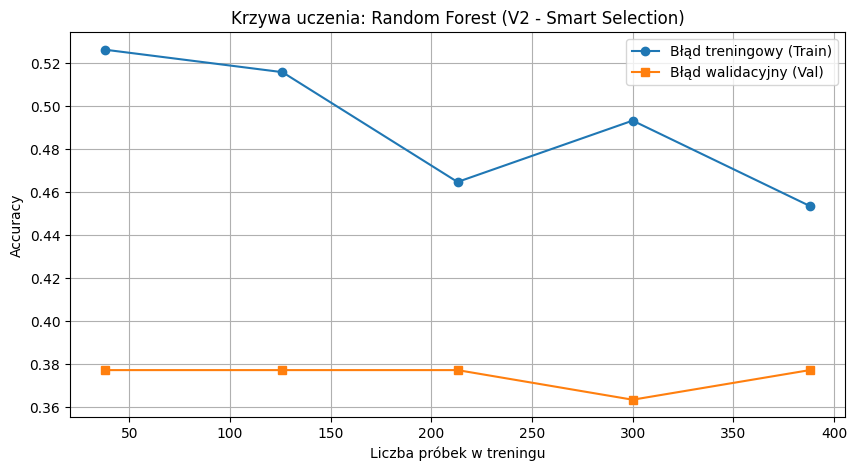

Wyniki Random Forest na zbiorze TESTOWYM (V2):
              precision    recall  f1-score   support

 Spadek (-1)       0.50      0.03      0.05       109
 Neutral (0)       0.41      0.34      0.37       116
  Wzrost (1)       0.34      0.73      0.46       107

    accuracy                           0.36       332
   macro avg       0.42      0.36      0.29       332
weighted avg       0.42      0.36      0.29       332



In [21]:
# 1. Fine-tuning Random Forest przy użyciu Optuna (Dataset V2)
def objective_rf_v2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 5),          # Restrykcyjna głębokość
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 50, 100), # Duże liście
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': 'balanced' # Dodaję balanced, żeby model powalczył o klasę -1
    }
    
    # PODMIANA NA V2
    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    rf.fit(X_train_v2, y_train_encoded)
    
    preds = rf.predict(X_val_v2)
    return accuracy_score(y_val_encoded, preds)

# Uruchomienie tuningu dla V2
study_rf_v2 = optuna.create_study(direction='maximize')
study_rf_v2.optimize(objective_rf_v2, n_trials=15)

# Trenowanie najlepszego modelu RF dla V2
best_params_rf_v2 = study_rf_v2.best_params
rf_final_v2 = RandomForestClassifier(**best_params_rf_v2, random_state=42)
# PODMIANA NA V2
rf_final_v2.fit(X_train_v2, y_train_encoded)

# 2. Wykres Krzywej Uczenia (Dla zestawu V2)
# Używamy tej samej funkcji co wcześniej (pamiętaj, aby funkcja plot_overfitting_analysis była zdefiniowana)
plot_overfitting_analysis(rf_final_v2, X_train_v2, y_train_encoded, "Krzywa uczenia: Random Forest (V2 - Smart Selection)")

# 3. Porównanie i Raport dla V2
print("Wyniki Random Forest na zbiorze TESTOWYM (V2):")
# PODMIANA NA V2
y_pred_rf_v2 = rf_final_v2.predict(X_test_v2)
print(classification_report(y_test_encoded, y_pred_rf_v2, target_names=['Spadek (-1)', 'Neutral (0)', 'Wzrost (1)']))